In [1]:
import glob
import os
import time
import importlib
from scipy import ndimage


import matplotlib.pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)

import numpy as np

import h5py  
import sys
from scipy.ndimage import gaussian_filter

In [2]:
import os
os.getcwd()

'/home/ss3428'

In [3]:
import multiprocessing as mp
print(mp.cpu_count())

56


In [4]:
from xtec.Preprocessing import Mask_Zeros              # to remove zero intensity points from data       
from xtec.Preprocessing import Threshold_Background    # for thresholding background intensity

from sklearn.mixture import GaussianMixture   # for GMM clustering

In [5]:
#search_dir = '/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/'
search_dir = "/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/"
Tlist=[15,25,50,75,100,125,150,175,200,225,250,275,300]


In [6]:
#search_dir = '/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/'
search_dir = "/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/"
arr = os.listdir(search_dir)
print(search_dir)

dir_arr = []
T_dir_dict = {}
for item in arr:
    if not item.endswith('.nxs'):
        dir_arr.append(search_dir+item+'/transform.nxs')
        T_dir_dict[item] = search_dir+item+'/transform.nxs'
        
#print(T_dir_dict)  
#print(T_dir_dict.keys())
Tlist = list(T_dir_dict.keys())
print(Tlist)


/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/
['15', '50', '90', '150', '300']


In [7]:
#arr = os.listdir('/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/')
arr = os.listdir('/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/')

print(arr)

['15', 'CsV3Sb5Snx_15.nxs', '50', 'CsV3Sb5Snx_50.nxs', '90', 'CsV3Sb5Snx_90.nxs', '150', 'CsV3Sb5Snx_150.nxs', '300', 'CsV3Sb5Snx_300.nxs', 'CsV3Sb5Snx_parent.nxs']


In [8]:
Tnames = []
for T in Tlist:
    Tsplit = str(T).split('.')
    if len(Tsplit) > 1:
        Tnames.append(Tsplit[0] + 'p' + Tsplit[1])
    else:
        Tnames.append(Tsplit[0])
#filepaths = ['/nfs/chess/id4baux/2024-1/postec-3946-a/nxrefine/Ag8GeS6/AGS1/Ag8GeS6_'+T+'.nxs' for T in Tnames] # list of file paths
filepaths = ['/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_'+T+'.nxs' for T in Tnames] # list of file paths
print(filepaths)



['/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_15.nxs', '/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_50.nxs', '/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_90.nxs', '/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_150.nxs', '/nfs/chess/id4baux/2024-1/wilson-3947-a/nxrefine/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_300.nxs']


In [9]:
doc = h5py.File(filepaths[0], 'r')
print(doc)
print(doc['entry/transform/data'].shape)





<HDF5 file "CsV3Sb5Snx_15.nxs" (mode r)>
(961, 1201, 1201)


In [10]:
doc = h5py.File(filepaths[0], 'r')
    
Qh=np.array(doc['entry/transform']['Qh'])
Qk=np.array(doc['entry/transform']['Qk'])
Ql=np.array(doc['entry/transform']['Ql'])

delta_Qh=Qh[1]-Qh[0]
delta_Qk=Qk[1]-Qk[0]
delta_Ql=Ql[1]-Ql[0]


doc.close()


print(Qh.shape,Qk.shape,Ql.shape)
print('Ql=',Ql[0],' to ',Ql[-1],np.round(delta_Ql,3))
print('Qk=',Qk[0],' to ', Qk[-1],np.round(delta_Qk,3))
print('Qh=', Qh[0],' to ', Qh[-1],np.round(delta_Qh,3))

(1201,) (1201,) (961,)
Ql= -24.0  to  24.0 0.05
Qk= -12.0  to  12.0 0.02
Qh= -12.0  to  12.0 0.02


In [11]:
x=abs(Qh-np.round(Qh))-0.5*delta_Qh
H_Bragg_ind=np.where(x<0)[0]

x=abs(Qk-np.round(Qk))-0.5*delta_Qk
K_Bragg_ind=np.where(x<0)[0]


x=abs(Ql-np.round(Ql))-0.5*delta_Ql
L_Bragg_ind=np.where(x<0)[0]


Qh_Bragg=Qh[H_Bragg_ind]
Qk_Bragg=Qk[K_Bragg_ind]
Ql_Bragg=Ql[L_Bragg_ind]

print('Qh Bragg', np.round(Qh_Bragg,3))
print('Qk Bragg', np.round(Qk_Bragg,3))
print('Ql_Bragg', np.round(Ql_Bragg,3))


cell_start_ind=[(p,q,r)  for p in L_Bragg_ind[0:-1] for q in K_Bragg_ind[0:-1] for r in H_Bragg_ind[0:-1]] 

cell_size=(int(L_Bragg_ind[1]-L_Bragg_ind[0]),int(K_Bragg_ind[1]-K_Bragg_ind[0]),int(H_Bragg_ind[1]-H_Bragg_ind[0]))
print('unit cell size (#L,#K,#H)=', cell_size)

num_cells=len(cell_start_ind)
print('num of cells=', num_cells )

Qh Bragg [-12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.
   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.]
Qk Bragg [-12. -11. -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.
   2.   3.   4.   5.   6.   7.   8.   9.  10.  11.  12.]
Ql_Bragg [-24. -23. -22. -21. -20. -19. -18. -17. -16. -15. -14. -13. -12. -11.
 -10.  -9.  -8.  -7.  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.
   4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.
  18.  19.  20.  21.  22.  23.  24.]
unit cell size (#L,#K,#H)= (20, 50, 50)
num of cells= 27648


In [12]:
sig=(0,0.0,0.0,0.0)#(T,H,K,L) no smooting
#sig=(0,0.5,0.5,0.5)#(T,H,K,L)

In [14]:
def Extract_smooth_unit_cell_data(sig, cpu_counter):
    
    data_slice={}
    smooth_window= (int(4*sig[1]), int(4*sig[2]), int(4*sig[3]))     

    
    unit_start=cell_start_ind[cpu_counter]

    if (((unit_start[0]+cell_size[0])>=len(Ql)) or 
        ((unit_start[1]+cell_size[1])>=len(Qk)) or 
        ((unit_start[2]+cell_size[2])>=len(Qh))):
            print('wrong cell shape')
            return None
    
    
    
    #get min and max indices of enlarged cell 
    l_min=max(0,unit_start[0]-smooth_window[0])
    k_min=max(0,unit_start[1]-smooth_window[1])
    h_min=max(0,unit_start[2]-smooth_window[2])

    l_max=min(len(Ql)-1,unit_start[0]+cell_size[0]+smooth_window[0])
    k_max=min(len(Qk)-1,unit_start[1]+cell_size[1]+smooth_window[1])
    h_max=min(len(Qh)-1,unit_start[2]+cell_size[2]+smooth_window[2])

    
    
    Qh_cell=Qh[h_min:h_max]
    Qk_cell=Qk[k_min:k_max]
    Ql_cell=Ql[l_min:l_max]



    # read data from this cell
    data = []
    num_T=len(filepaths)
    for filepath in filepaths:
        doc = h5py.File(filepath, 'r')
        dataT = doc['entry/transform/data'][l_min:l_max,k_min:k_max,h_min:h_max]
        data.append(dataT)
        doc.close()
    I = np.squeeze(data)   
    
    if (np.amax(I)  < 1):
        return data_slice  # skip empty slices
    
    I= gaussian_filter(I,sig)

    #get min and max indices unit cell inside this enlarged cell 
    l_min=max(0,smooth_window[0])
    k_min=max(0,smooth_window[1])
    h_min=max(0,smooth_window[2])

    l_max=min(I.shape[1],cell_size[0]+smooth_window[0])
    k_max=min(I.shape[2],cell_size[1]+smooth_window[1])
    h_max=min(I.shape[3],cell_size[2]+smooth_window[2])

    
    
    Qh_cell=Qh_cell[h_min:h_max]
    Qk_cell=Qk_cell[k_min:k_max]
    Ql_cell=Ql_cell[l_min:l_max]
    
    # clip down I to the unit cell
    I=I[:,l_min:l_max,k_min:k_max,h_min:h_max]
    
    try:
        masked    = Mask_Zeros(I)
        threshold = Threshold_Background(masked)
        num_thresholded  = threshold.data_thresholded.shape[1]
        if num_thresholded  == 0:
            return data_slice
    except:
        return data_slice   # if thresholding failed for this unit cell
    
    
    
    
    max_num_features = 5000
    sector_id=int(cpu_counter)*max_num_features
    
    structure_element = np.ones((3,3,3))    # to identify features if they are connected, even diagonally
    labeled_array, num_features = ndimage.label(threshold.thresholded,structure=structure_element)
                    # threshold.thresholded :  non_zero data(h,k,l)=1 if above cutoff 
                    # labelled_array(h,k,l) has connected features (#num_features) marked by different integers 
    labels= list(range(1,num_features+1))
    
    if(num_features>max_num_features):
        print('num features too large', num_features,max_num_features)
        return 
    
    
    # remove Bragg peaks
    
    #finding Bragg labels
    Bragg_inds = [(i,j,k) for i in [0,cell_size[0]-1] for j in [0,cell_size[1]-1] for k in [0,cell_size[2]-1]]
    Bragg_labels = [labeled_array[ind] for ind in Bragg_inds]   # labels at Brag_loc
    Bragg_labels = np.unique(Bragg_labels)

    # non bragg labels
    Non_Bragg_labels=np.setdiff1d(labels,Bragg_labels+[0])
    Non_Bragg_labels = np.unique(Non_Bragg_labels)

    NonBragg_mask = np.isin(labeled_array,Non_Bragg_labels)           # returns true for labeled arrays that match  NonBragg_labels
    NonBragg_ind  = np.array(np.where(NonBragg_mask)).transpose()    # h,k,l indices of non Bragg data, (#non_Bragg_data, 3) 
    
    # number of non bragg peaks
    num_NB= len(Non_Bragg_labels)
    # now for each peak (connected set of pixels) find peak avg, max, tot, and indices of pixels in the peak
    peak_avg = np.zeros((num_NB,num_T))       # peak averaged non bragg int, shape=(num_T, num_NB)
    peak_tot = np.zeros((num_NB,num_T))
    peak_max = np.zeros((num_NB,num_T))
    
    ind_in_peak={} #the hkl indices of all pixels in a peak 
    data_in_peak={} # intensity data of all pixels in a peak
     
    peak_label = np.zeros(num_NB) # labels of peak averaged non bragg intensities
    peak_COM   = np.zeros([num_NB,num_T,3])
    
    
    
    
        
    
    count=0
    for nbl in Non_Bragg_labels:
        mask_i  = np.isin(labeled_array,nbl)
        
        data_i  = I[:,mask_i]
        
        peak_tot[count,:] = np.sum(data_i, axis=1)   
        peak_avg[count,:] = np.mean(data_i, axis=1)  
        peak_max[count,:] = np.amax(data_i, axis=1)  
        
        
        peak_id = nbl+sector_id
        peak_label[count]   = peak_id      # label of the jth averaged Non Bragg data point, same as NonBragg_labels
        
        
        data_in_peak[peak_id]=data_i
        ind_i   = np.nonzero(mask_i)
        ind_in_peak[peak_id] = [ind_i[x]+unit_start[x] for x in [0,1,2]]
        
        
        
        for t in range(num_T):
            com=ndimage.center_of_mass(I[t]+0.001, labeled_array,nbl)
            l_com=(com[0]+unit_start[0])*(Ql[1]-Ql[0])+Ql[0]
            k_com=(com[1]+unit_start[1])*(Qk[1]-Qk[0])+Qk[0]
            h_com=(com[2]+unit_start[2])*(Qh[1]-Qh[0])+Qh[0]
            peak_COM[count,t,:]=np.array([l_com,k_com,h_com])
     
        count+=1

    data_slice['peak_avg'] = peak_avg
    data_slice['peak_tot'] = peak_tot
    data_slice['peak_max'] = peak_max
    
    data_slice['ind_in_peak']=ind_in_peak
    data_slice['data_in_peak']=data_in_peak
    
    
    data_slice['peak_label'] = peak_label
    
    data_slice['peak_COM']=peak_COM
    
    print('Completed', cpu_counter)
    return data_slice

In [15]:
import multiprocessing as mp
from functools import partial

In [16]:
pip install multiprocess

Note: you may need to restart the kernel to use updated packages.


In [17]:
cpu_counter=range(num_cells)
n_cpus= 3
start_time = time.time()
import multiprocess as mp
#import multiprocessing as mp
from functools import partial   # partial functions like: func(x,y,z), par=partial(func,2,3) gives par(1)= func(2,3,1)  

Preprocessing = partial(Extract_smooth_unit_cell_data,sig)
print('num of cpus', n_cpus)
#pool = mp.Pool(mp.cpu_count())
pool = mp.Pool(n_cpus) # Leave a couple prcs free
processed_data = pool.map(Preprocessing,cpu_counter)
run_time = time.time() - start_time
print("Total Run Time:",run_time)

num of cpus 3
Completed 4785
Completed 4786
Completed 4787
Completed 4788
Completed 4789
Completed 4790
Completed 4806
Completed 4807
Completed 4808
Completed 4809
Completed 4810
Completed 4811
Completed 4812
Completed 4813
Completed 4814
Completed 4815
Completed 2549
Completed 2550
Completed 2551
Completed 2552
Completed 4828
Completed 4829
Completed 4830
Completed 4831
Completed 4832
Completed 2574
Completed 2575
Completed 4833
Completed 2576
Completed 2577
Completed 4834
Completed 2578
Completed 4835
Completed 4836
Completed 4837
Completed 2597
Completed 4838
Completed 4839
Completed 4851
CompletedCompleted 4852
 2598
Completed 4853
Completed 4854
Completed 4855
Completed 2599
Completed 4856
Completed 4857
Completed 4858
Completed 2600
Completed 2601
Completed 4859
Completed 2602
Completed 4860
Completed 4861
Completed Completed4862 2620

Completed 4863
Completed 2621
Completed 2622
Completed 2623
Completed 4875
Completed 4876
Completed 2624
Completed 2625
Completed 2626
Completed 4

/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3441: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/numpy/core/_methods.py:189: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)
/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/numpy/core/fromnumeric.py:3724: RuntimeWarning: Degrees of freedom <= 0 for slice
  **kwargs)


Completed 5573


/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in true_divide
  subok=False)
/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/numpy/core/_methods.py:254: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)
/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/xtec/Preprocessing.py:341: RuntimeWarning: invalid value encountered in log
  DLogKL = (np.log(KL_div_plus_dx) - np.log(KL_div)) / self.bin_size
/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/xtec/Preprocessing.py:341: RuntimeWarning: divide by zero encountered in log
  DLogKL = (np.log(KL_div_plus_dx) - np.log(KL_div)) / self.bin_size


Completed 7063
Completed Completed 7064
3778
Completed 5574
Completed 7065
Completed 7066
Completed 5575
CompletedCompleted 3779
 5576
Completed 7067
Completed 3780
Completed 5577
Completed 3781
Completed 7068
Completed 5578
Completed 5579
Completed 7069
Completed 5580Completed
 7070
Completed Completed5581 3795

Completed 7071
Completed 3796
Completed 7072
Completed 7073
Completed 5595
Completed 3797
Completed 7074
Completed 5596
Completed 3798
Completed 5597
Completed Completed 7075
3799
CompletedCompleted 5598
 7076
Completed 5599
Completed 5600
Completed 7077
Completed 5601
Completed 7078
Completed 5602
Completed 3800
Completed 7085
Completed 5603
Completed 7086
Completed 5604
Completed 7087
Completed 3801
Completed 7088
Completed 7089
Completed 5619
Completed 5620
Completed 5621
Completed 7090
Completed 5622
Completed 3802
Completed 7091
Completed 5623
Completed 3803
CompletedCompleted 3804 
7092
Completed 7093
Completed 7094
Completed 5624
Completed 7095
Completed 5625
Completed 

...

Completed 23153
Completed 20992
Completed 23173
Completed Completed23174
 20993
Completed 19914
Completed Completed23175 20994

Completed 19915
Completed 20995
Completed 19916
Completed 23176
Completed 19921
Completed 21005Completed 
23177
Completed Completed21006
 19922
Completed 21007
Completed 19923
Completed 19924
Completed 19925
Completed 21008
Completed 21009
Completed 23196
Completed 19926
Completed 23197
Completed 23198
Completed 21010
Completed 23199
Completed 23200
Completed 23201
Completed 21011
Completed 21012
Completed 21013
Completed Completed 19927
23219
Completed 19928
Completed 23220
Completed 21014
Completed 19929
Completed 19930
Completed 23221
Completed 19931Completed
 21015
Completed 23222
Completed 19932
Completed 21016
Completed 19933
Completed 23223
Completed 19934
Completed 21017
CompletedCompleted 23224
 19935
Completed 21018
Completed 19936
Completed 23225
Completed 21019
Completed 19937
Completed 21028
Completed 21029
CompletedCompleted  21030
23242
Complete

/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/xtec/Preprocessing.py:269: RuntimeWarning: divide by zero encountered in true_divide
  * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))


23392


/nfs/chess/user/ss3428/anaconda3_jpcr/envs/xtec/lib/python3.7/site-packages/xtec/Preprocessing.py:269: RuntimeWarning: invalid value encountered in multiply
  * np.exp(-((x - mean) ** 2) / (2 * std_dev ** 2))


Completed 21180
Completed 23393
Completed 21194
Completed 21195
Completed 21196
Completed 21197Completed 
23410
Completed 21198
Completed 21199
Completed 23411
Completed 21200
Completed 23412
Completed 20200
Completed 23413
Completed 23414
Completed 23415
Completed 20221
Completed 20222
Completed 20223
Completed 20224
Completed 20225
Completed 20244
Completed 20245
Completed 20246
Completed 20247
Completed 20248
Completed 20249
Completed 20250
Completed 20267
Completed 20268
Completed 20269
Completed 20270
Completed 20271
Completed 20272
Completed 20273
Completed 20274
Completed 20290
Completed 20291
Completed 20292
Completed 20293
Completed 21374
Completed 21375
Completed 20294
Completed 21376
Completed 21377
Completed 20295
Completed 20296
Completed 20297
Completed 20298
Completed 21397
Completed 21398
Completed 21399
Completed 20313
Completed 20314
Completed 21400
Completed 20315
Completed 21401
Completed 20316
Completed 20317
Completed 20318
Completed 20319
Completed 20320
Complete

In [17]:
import pickle

pickle.dump( processed_data, open( "/nfs/chess/id4baux/suchi/XTEC/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_ACS5-11-1_CWD_sig0.p", "wb" ) )
#pickle.dump( processed_data, open( "/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/Ag8GeS6_AGS1_CWD_sig0.p", "wb" ) )

In [18]:
import pickle
processed_data = pickle.load(open("/nfs/chess/id4baux/suchi/XTEC/CsV3Sb5Snx/ACS5-11-1/CsV3Sb5Snx_ACS5-11-1_CWD_sig0.p", "rb" ) )
#processed_data = pickle.load(open("/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/Ag8GeS6_AGS1_CWD_sig0.p", "rb" ) )

In [19]:

peak_avg_list = []
peak_tot_list = []
peak_max_list = []
peak_COM_list = []
peak_label_list = []

ind_in_peak={}
data_in_peak={}

for num, slices in enumerate(processed_data):
    if(bool(slices)):
        peak_avg_list.append(slices['peak_avg'])
        peak_tot_list.append(slices['peak_tot'])
        peak_max_list.append(slices['peak_max'])
        peak_COM_list.append(slices['peak_COM'])
        peak_label_list.append(slices['peak_label'])
        
        ind_in_peak.update(slices['ind_in_peak'])
        data_in_peak.update(slices['data_in_peak'])
        
        
peak_avg = np.vstack(peak_avg_list)  #(num_T, num_NB_data)
peak_tot = np.vstack(peak_tot_list)  #(num_T, num_NB_data)
peak_max = np.vstack(peak_max_list)  #(num_T, num_NB_data)
peak_COM = np.vstack(peak_COM_list)  #(num_T, num_NB_data)
peak_label=np.hstack(peak_label_list)


print(peak_avg.shape)
print(peak_tot.shape)
print(peak_max.shape)
print(peak_COM.shape)
print(peak_label.shape)

print(len(ind_in_peak))
print(len(data_in_peak))

(377984, 5)
(377984, 5)
(377984, 5)
(377984, 5, 3)
(377984,)
377984
377984


In [20]:
XTEC_D_data=[]
XTEC_D_ind=[]
for i in peak_label:
    XTEC_D_data.append(data_in_peak[i])
    XTEC_D_ind.append(ind_in_peak[i])

XTEC_D_data=np.hstack(XTEC_D_data)
XTEC_D_ind=np.hstack(XTEC_D_ind)

print(XTEC_D_data.shape)
print(XTEC_D_ind.shape)

(5, 1224648)
(3, 1224648)


In [21]:
x_train = np.array(Tlist)
data_post_thresh = (XTEC_D_data)
data_post_thresh_no_mean = (data_post_thresh-np.mean(data_post_thresh,axis=0))/(0.01+np.std(data_post_thresh,axis=0))
X=data_post_thresh_no_mean.transpose() 

print('Data shape',X.shape)

Data shape (1224648, 5)


In [22]:
n_clusters=4

In [23]:
gm = GaussianMixture(n_components=n_clusters,covariance_type='diag',init_params='kmeans',n_init=10).fit(X)

In [24]:
import pickle
pickle.dump( {'gm':gm}, open( "/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/XTECD_Ag8GeS6_AGS1_gm.p", "wb" ) )

In [25]:
import pickle
obj=pickle.load(  open( "/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/XTECD_Ag8GeS6_gm.p", "rb" ) )
gm=obj['gm']   # loading the stored gmm model


cluster_assigns=gm.predict(X)
n_clusters=max(cluster_assigns)+1

cluster_means=gm.means_
cluster_covs=gm.covariances_


print(n_clusters)
print(cluster_means.shape)
print(cluster_covs.shape)
print(cluster_assigns.shape)

4
(4, 5)
(4, 5)
(1224648,)


In [26]:
color_list = ['firebrick', 'teal', 'gainsboro', 'purple', 'yellow', 'orange', 'pink', 'black', 'grey', 'cyan']

#marker_list=['o','s', '+']
#line_list=['-','--', ':']
#lw_list=[2,2,2]

marker_list=['o','s','p', '+']
line_list=['-','--','-.', ':']
lw_list=[2,2,2,2]

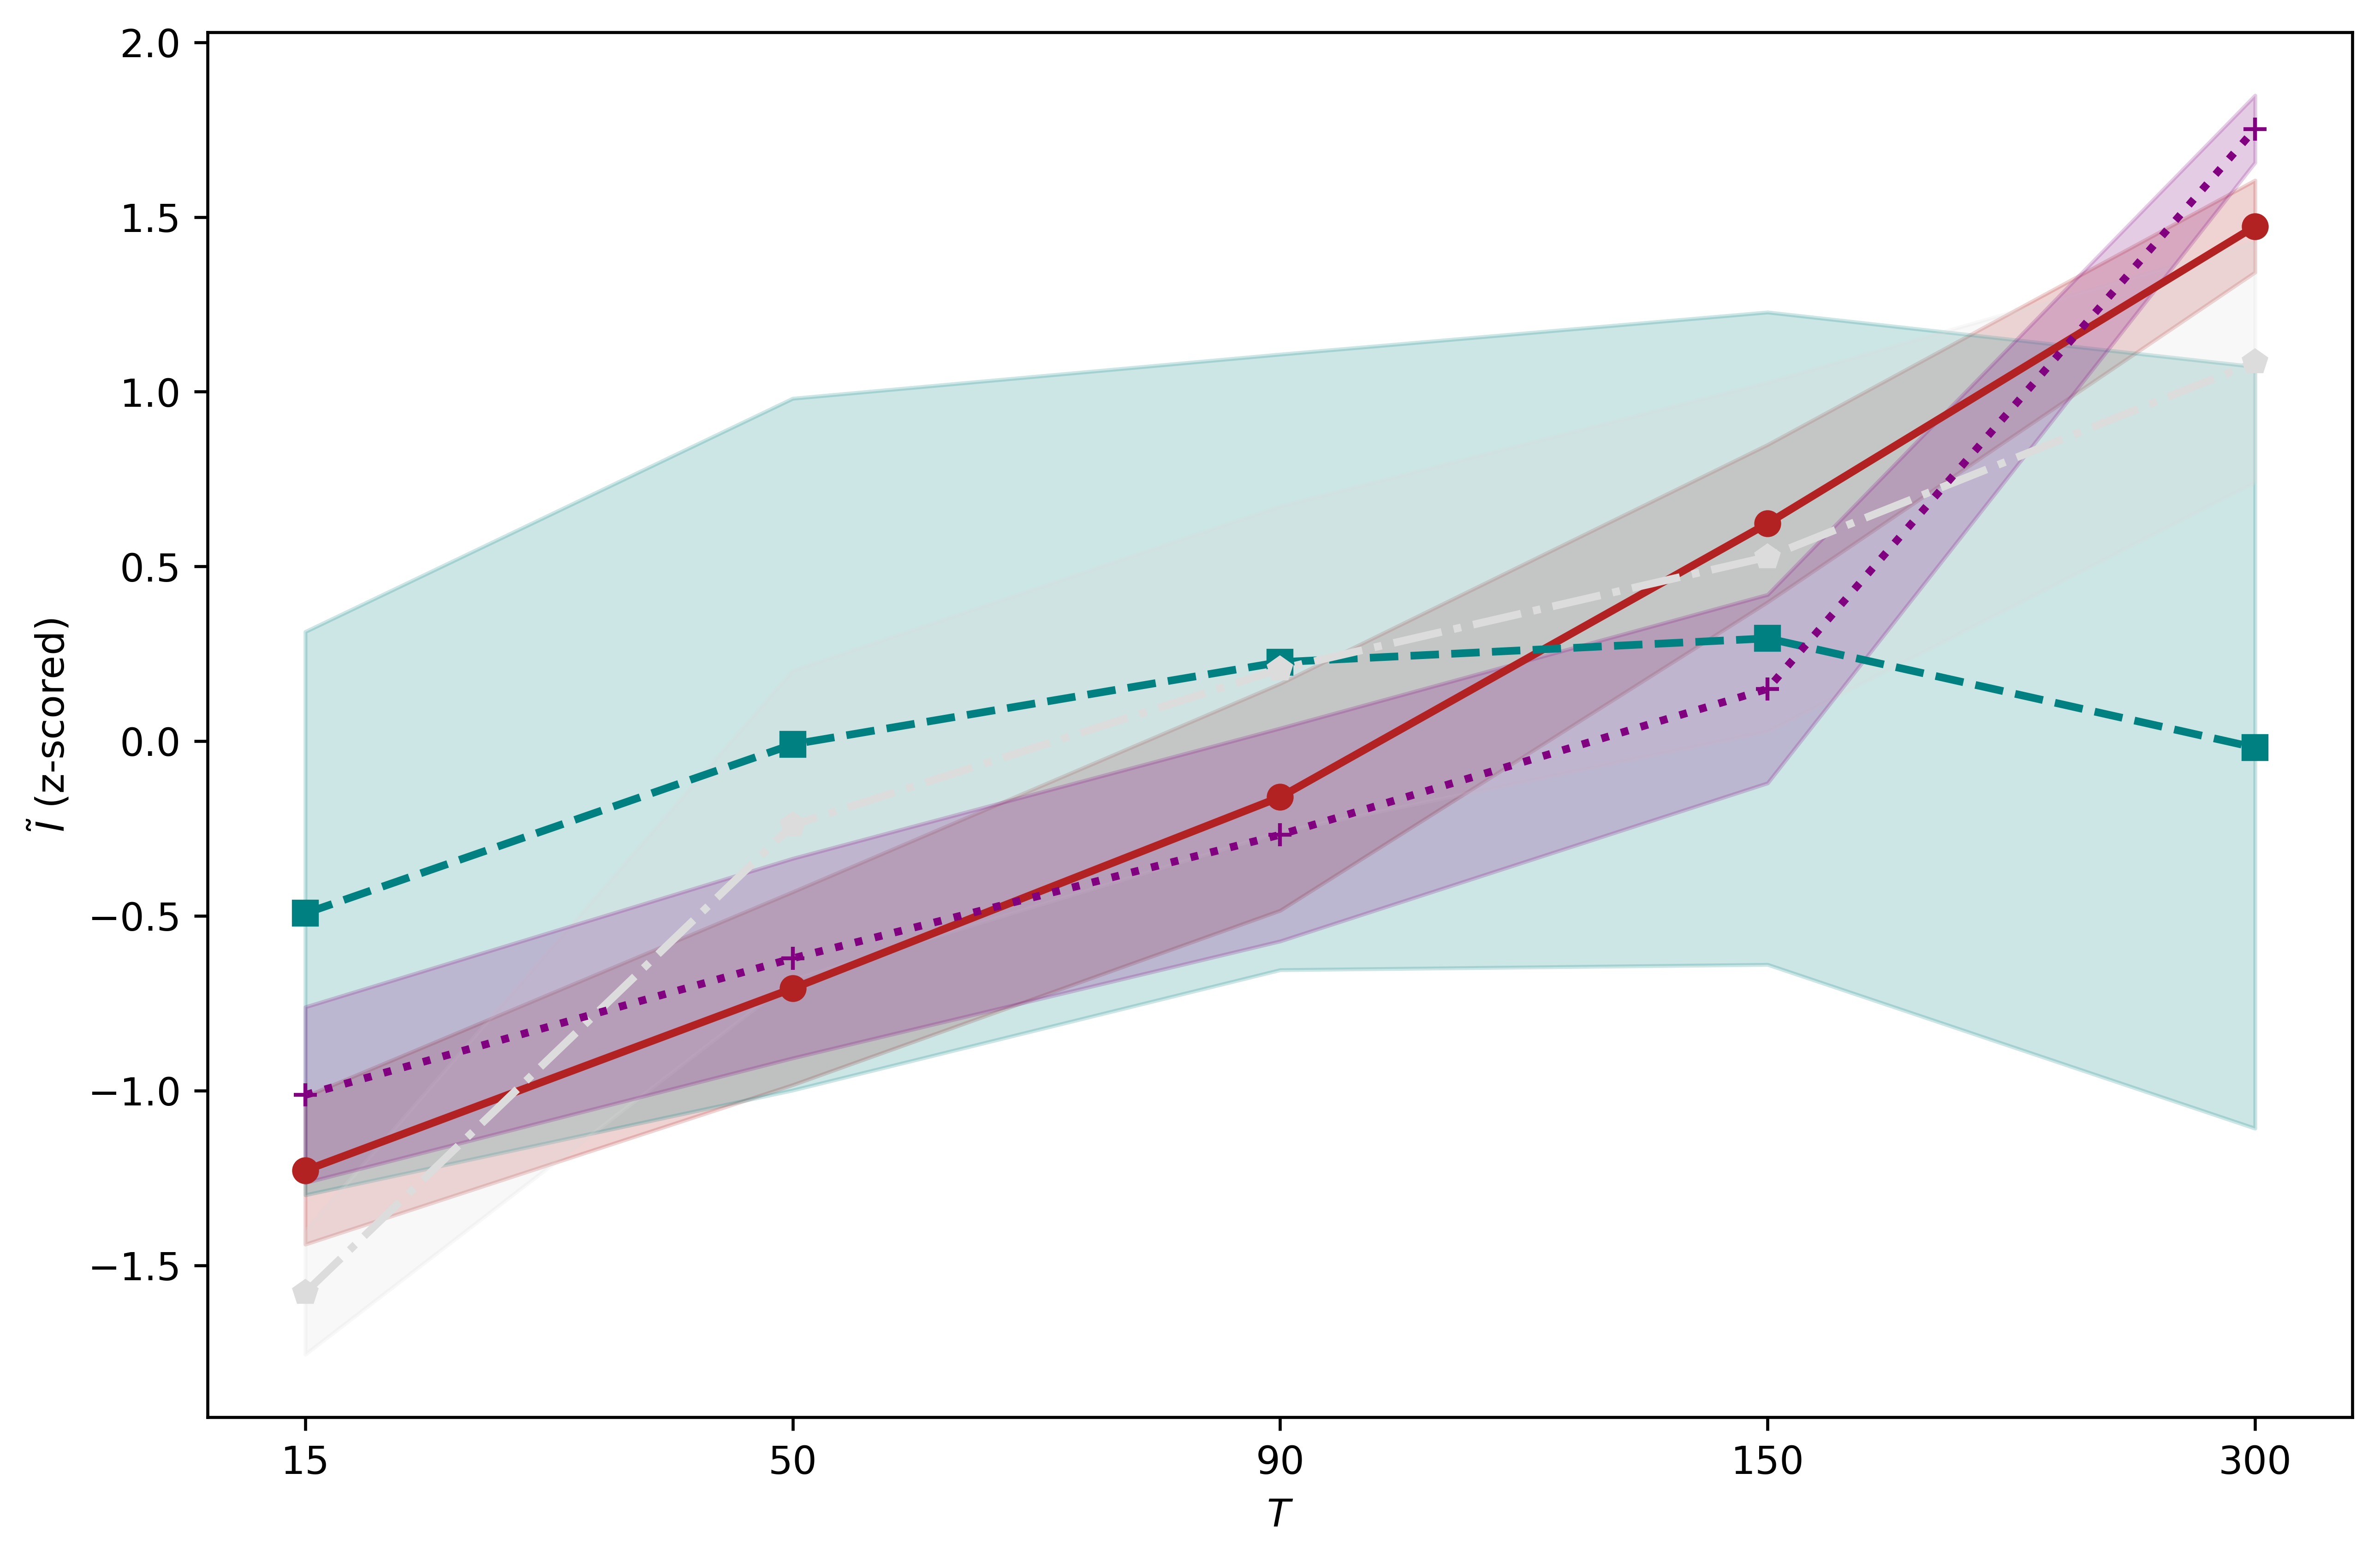

In [30]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6.5),dpi=600)
ax = plt.gca()


cluster_mean=[]
cluster_std=[]

for i in (range(n_clusters)):
    yc=cluster_means[i]
    yc_std=(cluster_covs[i])**0.5
    plt.plot(Tlist,yc,color=color_list[i], linestyle=line_list[i],marker=marker_list[i],lw=lw_list[i]);
    plt.gca().fill_between(Tlist,yc-yc_std,yc+ yc_std, color=color_list[i],alpha=0.2)
    
    cluster_mean.append(yc)    
    cluster_std.append(yc_std)

plt.xlabel(f'$T$',size=10)
plt.ylabel(r'$\tilde{I}$ (z-scored)',size=10)
#plt.title(r'Cluster mean and std',size=50)


#handles, labels = ax.get_legend_handles_labels()
#ax.legend(reversed(handles), reversed(labels),frameon=False, fontsize=16,ncol=2)

plt.xticks(size=10);
plt.yticks(size=10);

plt.savefig('/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/XTECD_Ag8GeS6_cluster.jpg')
plt.savefig('/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/XTECD_Ag8GeS6_cluster.pdf')

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_Q_hist(ax_id):
    
    KDE_list=[True]*10
    if ax_id==0 :
        Q_ax=Ql
        
    if ax_id==1 :
        Q_ax=Qk
    if ax_id==2 :
        Q_ax=Qh
        #KDE_list=[True,False,True]
        

    

    for i in range(n_clusters):
        cluster_mask_i = (cluster_assigns == i)
    
        yc=XTEC_D_ind[ax_id,cluster_mask_i]
        
        yc=Q_ax[yc]
        yc=yc-np.floor(yc)
        
        plt.figure()
        #sns.distplot(yc,  kde=True,norm_hist=True, color=color_list[i], kde_kws={'linewidth': 4})
        
        
        sns.histplot(data=yc, stat='probability',bins=40, kde=KDE_list[i],edgecolor=None, color=color_list[i],line_kws={'linewidth': 3})
    
        plt.yscale("linear")
        if ax_id==2:
            L_BZ[i]=yc
            plt.xlabel('H (reduced zone)',size=20)
        if ax_id==1:
            K_BZ[i]=yc
            plt.xlabel('K (reduced zone)',size=20)
        if ax_id==0:
            H_BZ[i]=yc
            plt.xlabel('L (reduced zone)',size=20)
        
        
        
        plt.ylabel('Pixel density',size=20)
        plt.xlim([0,1])
        plt.xticks([0,0.33,0.5,0.67,1],size=18)
        plt.ylim([0,0.15])
        plt.yticks(size=0)
    
        ax=plt.gca()
        ax.yaxis.grid(False) # Hide the horizontal gridlines
        ax.xaxis.grid(True)
        ax.yaxis.set_major_locator(MultipleLocator(0.2))

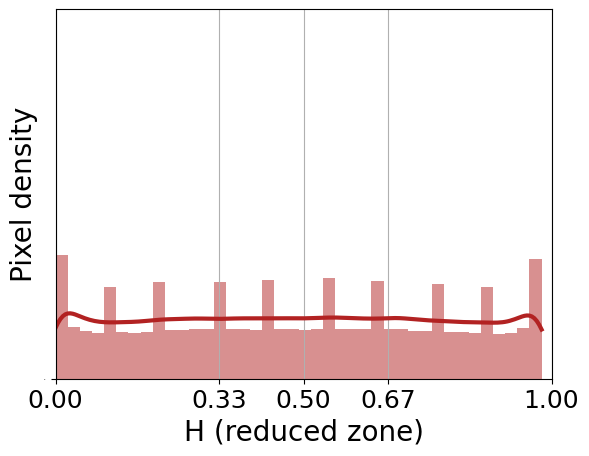

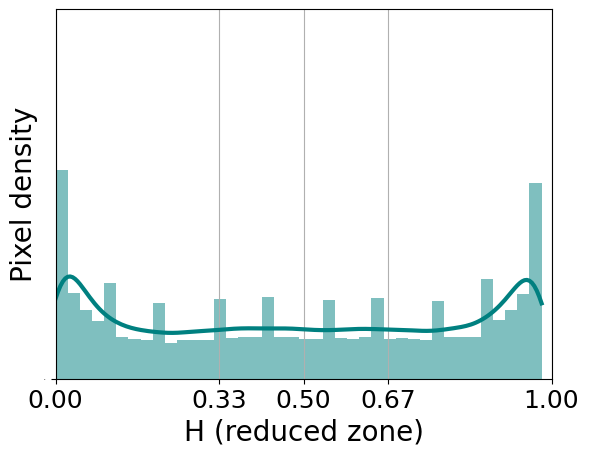

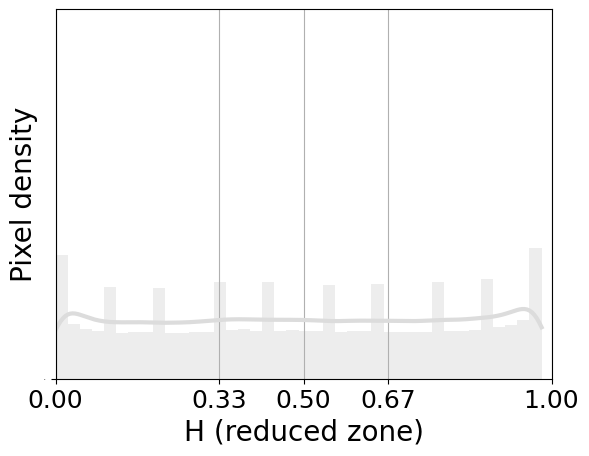

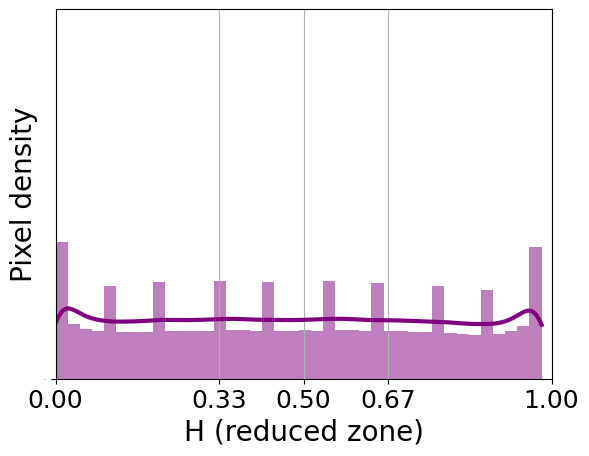

In [32]:
L_BZ={}
plot_Q_hist(2)
plt.savefig('/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/XTECD_Ag8GeS6_cluster_L_BZ_3.jpg')
plt.savefig('/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/XTECD_Ag8GeS6_cluster_L_BZ_3.pdf')


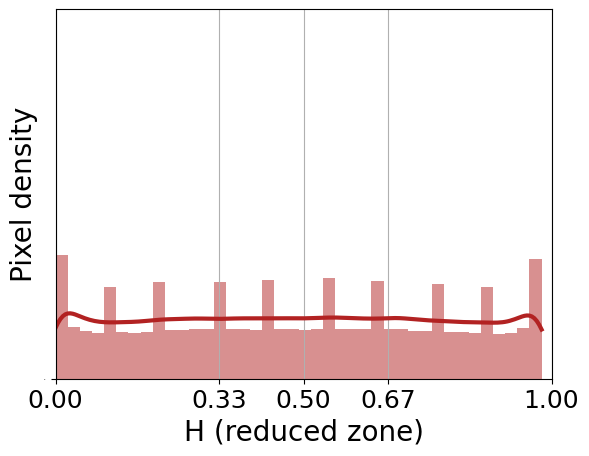

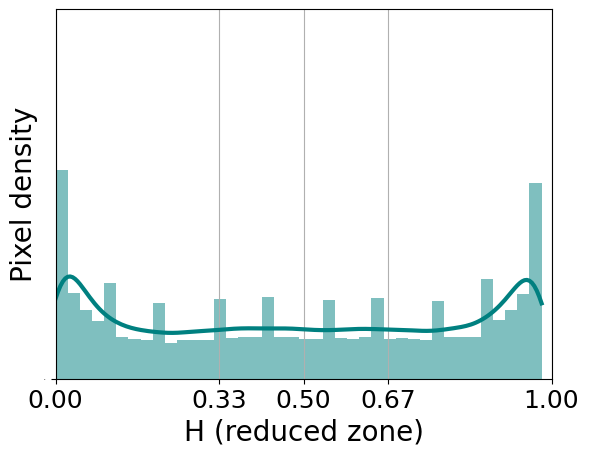

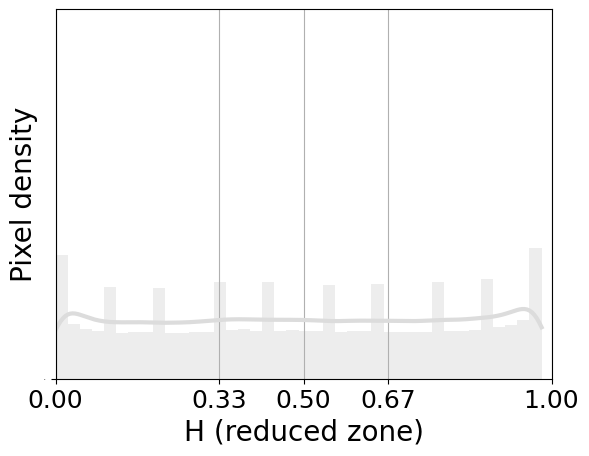

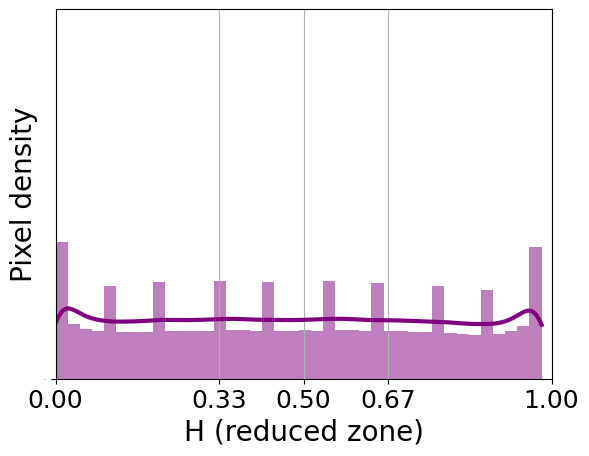

In [34]:
K_BZ={}
plot_Q_hist(2)
#plt.savefig('K_BZ_3.png')

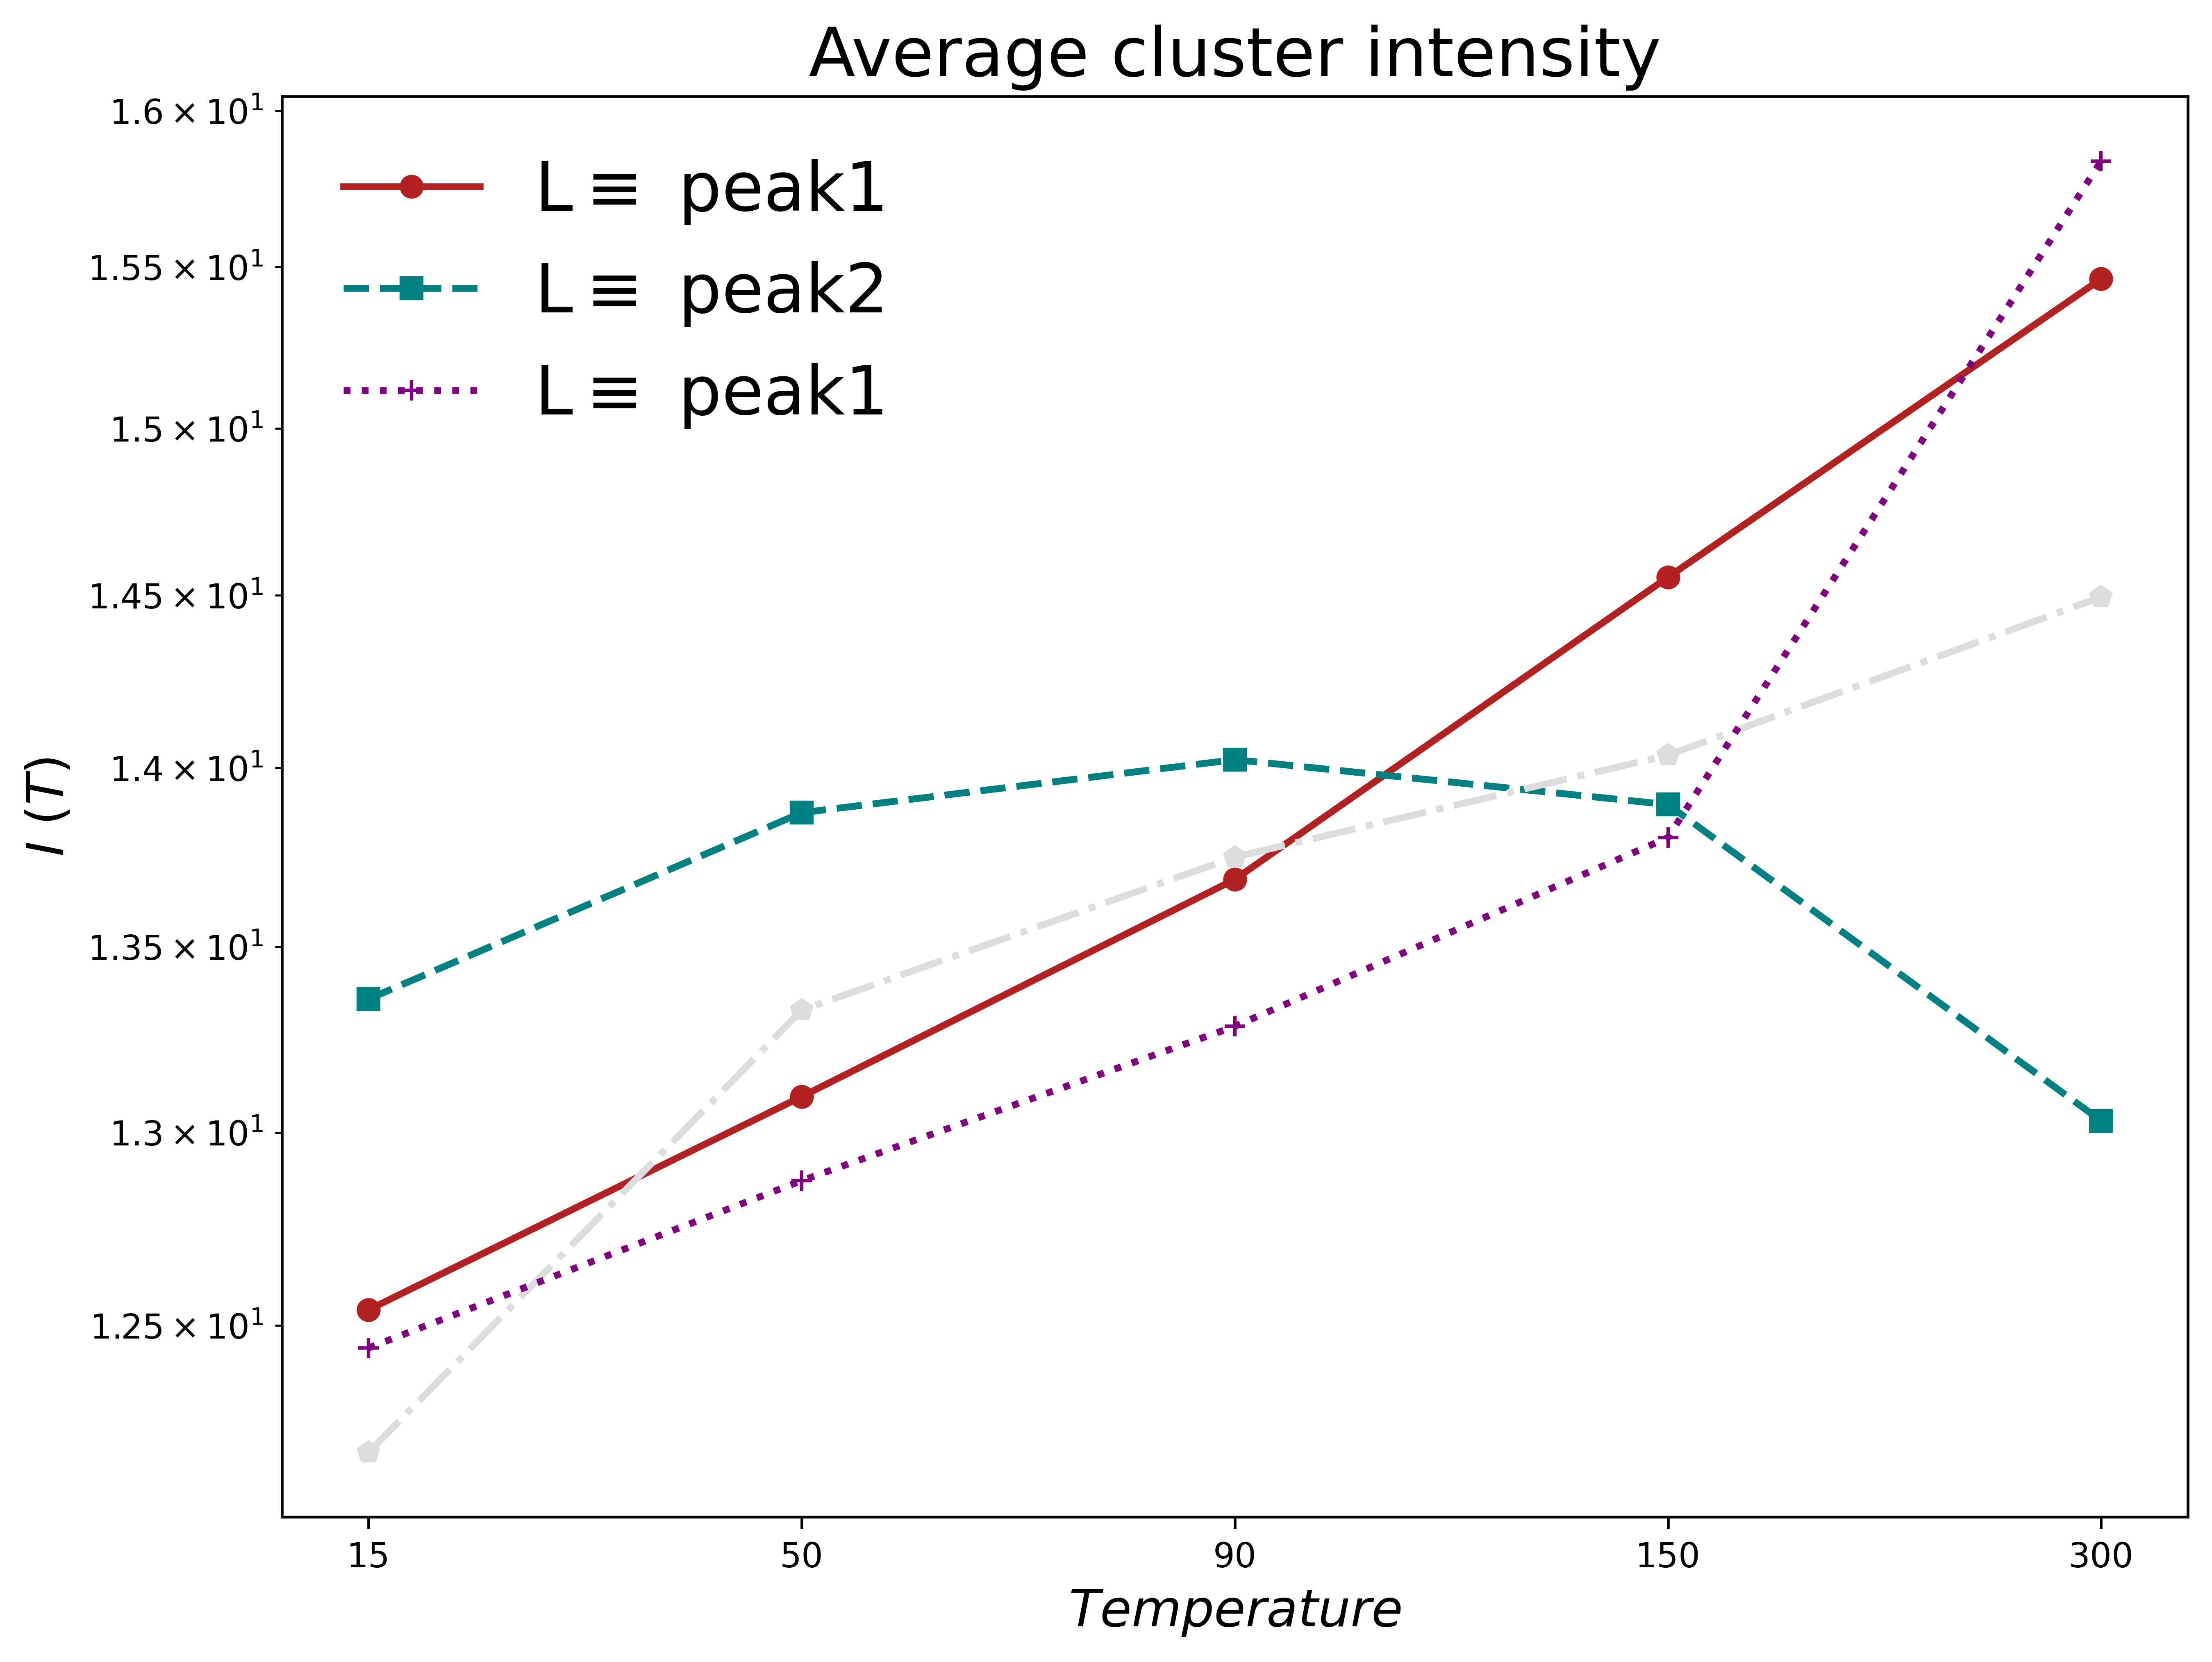

In [35]:
I_cluster_avg=[]


plt.figure(figsize=(10,7.5),dpi=600)
legends=[r'L$\equiv$ peak1',r'L$\equiv$ peak2',None]*5
for i in (range(n_clusters)):

    yc=np.mean(XTEC_D_data[:,cluster_assigns==i],axis=1)
    I_cluster_avg.append(yc)

    plt.plot(Tlist,yc,color=color_list[i], linestyle=line_list[i],marker=marker_list[i],lw=lw_list[i],label=legends[i]);
    
    
plt.xlabel(f'$Temperature $',size=15)
plt.ylabel(r'$I$ ($T$)',size=15)
plt.title(r'Average cluster intensity',size=20)
plt.legend(fontsize=20,frameon=False)
plt.yscale('log')

plt.xticks(size=10);
plt.yticks(size=10);
plt.savefig('/nfs/chess/id4baux/suchi/XTEC/Ag8GeS6/AGS1/cluster_4_plot_sig.png')

In [ ]:
plot_Q_hist(2)